# 관광지 클러스터링 v2
- 입력: `output/tour_master.csv`, `output/visitor_clean.csv`
- 출력: `output/tour_clustered.csv`
- **셀 순서대로 실행하면 됩니다**

In [1]:
# ── 셀 1: 라이브러리 + 데이터 로드 ──────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('./output')

CAT2_MAP = {
    'A0101':'자연관광지','A0102':'관광자원',
    'A0201':'역사관광지','A0202':'휴양관광지',
    'A0203':'체험관광지','A0204':'산업관광지',
    'A0205':'건축/조형물','A0206':'문화시설',
    'A0301':'레포츠소개','A0302':'육상레포츠',
    'A0303':'수상레포츠','A0304':'항공레포츠','A0305':'복합레포츠',
}
AREA_MAP = {
    '1':'서울','2':'인천','3':'대전','4':'대구','5':'광주',
    '6':'부산','7':'울산','8':'세종','31':'경기','32':'강원',
    '33':'충북','34':'충남','35':'경북','36':'경남',
    '37':'전북','38':'전남','39':'제주',
}

df = pd.read_csv(OUTPUT_DIR / 'tour_master.csv')

# 위경도 강제 숫자 변환 (핵심!)
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# 위경도 없는 행 제거
before = len(df)
df = df.dropna(subset=['latitude','longitude']).reset_index(drop=True)
print(f'위경도 결측 제거: {before} → {len(df)}건')

# 카테고리 매핑
type_to_cat1 = {'관광지':'A01','문화시설':'A02','레포츠':'A03'}
df['cat1']     = df['cat1'].fillna(df['content_type_name'].map(type_to_cat1))
df['cat2_name']= df['cat2'].map(CAT2_MAP).fillna('기타')
df['area_name'] = df['area_code'].dropna().astype(int).astype(str).reindex(df.index).map(AREA_MAP)
# NaN인 area_code는 주소에서 시도명 추출
addr_map = {'서울':'서울','부산':'부산','대구':'대구','인천':'인천','광주':'광주',
            '대전':'대전','울산':'울산','세종':'세종','경기':'경기','강원':'강원',
            '충청북':'충북','충청남':'충남','경상북':'경북','경상남':'경남',
            '전북':'전북','전라남':'전남','제주':'제주'}
def addr_to_area(addr):
    if pd.isna(addr): return None
    for k, v in addr_map.items():
        if k in str(addr): return v
    return None

df['area_name'] = df['area_name'].fillna(df['address'].apply(addr_to_area))

print(f'로드 완료: {len(df):,}건')
print(f'위경도 샘플:')
print(df[['name','latitude','longitude']].head(3).to_string())

위경도 결측 제거: 19223 → 19223건
로드 완료: 19,223건
위경도 샘플:
            name   latitude   longitude
0            가거도  34.052061  125.126386
1         가계해수욕장  34.435459  126.354741
2  가고파 꼬부랑길 벽화마을  35.207726  128.569630


In [2]:
# ── 셀 2: 시도별 DBSCAN 클러스터링 ──────────────────────────
DENSE_AREAS = {'서울','부산','대구','인천','광주','대전','울산'}
EPS_DENSE, EPS_RURAL, MIN_SAMPLES = 1, 3, 2

# numpy 배열로 직접 관리 (df.loc 할당 문제 우회)
cluster_labels = np.full(len(df), -1, dtype=int)
offset = 0

for area in sorted(df['area_name'].dropna().unique()):
    mask = (df['area_name'] == area).values
    sub_idx = np.where(mask)[0]  # 정수 인덱스

    if len(sub_idx) < 2:
        continue

    coords = np.radians(
        df.iloc[sub_idx][['latitude','longitude']].values.astype(float)
    )

    # 유효한 좌표만
    valid = ~np.isnan(coords).any(axis=1)
    if valid.sum() < 2:
        continue

    eps_km = EPS_DENSE if area in DENSE_AREAS else EPS_RURAL
    labels = DBSCAN(
        eps=eps_km / 6371,
        min_samples=MIN_SAMPLES,
        algorithm='ball_tree',
        metric='haversine'
    ).fit_predict(coords[valid])

    # 유효 좌표 위치에만 라벨 할당
    valid_sub_idx = sub_idx[valid]
    adjusted = np.where(labels == -1, -1, labels + offset)
    cluster_labels[valid_sub_idx] = adjusted

    max_label = labels.max() if labels.max() >= 0 else -1
    offset += max_label + 1

    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    print(f'{area:8s} | eps={eps_km}km | 클러스터 {n_c:3d}개 | 단독 {(labels==-1).sum():4d}개')

df['space_cluster'] = cluster_labels

n_clusters = len(set(cluster_labels[cluster_labels != -1]))
n_noise    = (cluster_labels == -1).sum()
sizes      = df[df['space_cluster'] != -1]['space_cluster'].value_counts()

print(f'\n✅ 전체 클러스터: {n_clusters:,}개')
print(f'단독: {n_noise:,}개 ({n_noise/len(df)*100:.1f}%)')
print(f'최대: {sizes.max()}개 / 중앙값: {sizes.median():.0f}개')
print(f'TOP 5:\n{sizes.head()}')

강원       | eps=3km | 클러스터 159개 | 단독  101개
경기       | eps=3km | 클러스터  48개 | 단독   31개
경남       | eps=3km | 클러스터 112개 | 단독   78개
경북       | eps=3km | 클러스터 172개 | 단독  127개
광주       | eps=1km | 클러스터  40개 | 단독   40개
대구       | eps=1km | 클러스터  64개 | 단독   82개
대전       | eps=1km | 클러스터  31개 | 단독   36개
부산       | eps=1km | 클러스터  46개 | 단독   55개
서울       | eps=1km | 클러스터  34개 | 단독   21개
세종       | eps=3km | 클러스터   7개 | 단독    1개
울산       | eps=1km | 클러스터  42개 | 단독   55개
인천       | eps=1km | 클러스터 107개 | 단독  104개
전남       | eps=3km | 클러스터 195개 | 단독  121개
전북       | eps=3km | 클러스터  94개 | 단독   51개
제주       | eps=3km | 클러스터  10개 | 단독    3개
충남       | eps=3km | 클러스터 110개 | 단독   52개
충북       | eps=3km | 클러스터  66개 | 단독   41개

✅ 전체 클러스터: 1,337개
단독: 1,049개 (5.5%)
최대: 2336개 / 중앙값: 4개
TOP 5:
space_cluster
159     2336
672     1027
1151     727
11       367
208      285
Name: count, dtype: int64


In [3]:
# ── 셀 3 전체 교체 ───────────────────────────────────────────
def safe_mode(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else '기타'

# cat2 없으면 content_type_name으로 보완
df['cat2_filled'] = df['cat2_name'].replace('기타', np.nan).fillna(
    df['content_type_name']
)

clustered = df[df['space_cluster'] != -1]

cluster_info = (
    clustered.groupby('space_cluster')
    .agg(
        cluster_theme=('cat2_filled',  safe_mode),
        cluster_area =('area_name',    safe_mode),
        cluster_lat  =('latitude',     'mean'),
        cluster_lon  =('longitude',    'mean'),
        cluster_size =('content_id',   'count'),
    )
    .reset_index()
)

df = df.merge(cluster_info, on='space_cluster', how='left')
df['cluster_theme'] = df['cluster_theme'].fillna(df['cat2_filled'])
df['cluster_area']  = df['cluster_area'].fillna(df['area_name'])
df['cluster_lat']   = df['cluster_lat'].fillna(df['latitude'])
df['cluster_lon']   = df['cluster_lon'].fillna(df['longitude'])
df['cluster_size']  = df['cluster_size'].fillna(1).astype(int)

df['cluster_id'] = df.apply(
    lambda r: f"{r['cluster_area']}_{r['cluster_theme']}_{int(r['space_cluster'])}"
    if r['space_cluster'] != -1
    else f"단독_{r['area_name']}_{r['content_id']}",
    axis=1
)

print('✅ 테마 레이블 완료')
print(f'\n클러스터 테마 분포:')
print(df[df['space_cluster']!=-1]['cluster_theme'].value_counts().to_string())

✅ 테마 레이블 완료

클러스터 테마 분포:
cluster_theme
관광지       6131
육상레포츠     4028
역사관광지     2995
문화시설      2652
자연관광지     1835
레포츠        142
건축/조형물     137
체험관광지      111
휴양관광지       71
관광자원        35
수상레포츠       19
산업관광지       18


In [4]:
# ── 셀 4: visitor 매칭 ───────────────────────────────────────
visitor = pd.read_csv(OUTPUT_DIR / 'visitor_clean.csv')

baseline = (
    visitor[
        visitor['year'].between(2016, 2019) &
        visitor['visitors_total'].notna()
    ]
    .groupby('site')['visitors_total']
    .mean()
    .reset_index()
    .rename(columns={'visitors_total':'avg_monthly_visitors','site':'name'})
)

df = df.merge(baseline, on='name', how='left')
matched = df['avg_monthly_visitors'].notna().sum()
print(f'visitor 매칭: {matched}개 ({matched/len(df)*100:.1f}%)')
print(f'미매칭: {len(df)-matched}개')

visitor 매칭: 1161개 (6.0%)
미매칭: 18062개


In [5]:
# ── 셀 5: 저장 ───────────────────────────────────────────────
out = OUTPUT_DIR / 'tour_clustered.csv'
df.to_csv(out, index=False, encoding='utf-8-sig')
print(f'✅ 저장: {out}')
print(f'   관광지: {len(df):,}개')
print(f'   클러스터: {df["space_cluster"].nunique()-1:,}개')
print(f'   컬럼: {list(df.columns)}')
df[['name','area_name','cat2_name','cluster_id','cluster_size','avg_monthly_visitors']].head(5)

✅ 저장: output\tour_clustered.csv
   관광지: 19,223개
   클러스터: 1,337개
   컬럼: ['content_id', 'content_type_id', 'content_type_name', 'name', 'address', 'area_code', 'sigungu_code', 'cat1', 'cat2', 'cat3', 'longitude', 'latitude', 'tel', 'image_url', 'cat2_name', 'area_name', 'space_cluster', 'cat2_filled', 'cluster_theme', 'cluster_area', 'cluster_lat', 'cluster_lon', 'cluster_size', 'cluster_id', 'avg_monthly_visitors']


,name,area_name,cat2_name,cluster_id,cluster_size,avg_monthly_visitors
0,가거도,전남,자연관광지,전남_관광지_862,2,741.8125
1,가계해수욕장,전남,자연관광지,전남_관광지_863,20,NaN
2,가고파 꼬부랑길 벽화마을,경남,기타,경남_관광지_207,164,NaN
3,가곡유황온천&스파,강원,휴양관광지,강원_관광지_0,3,NaN
4,가곡유황족욕체험장,강원,기타,강원_관광지_0,3,NaN


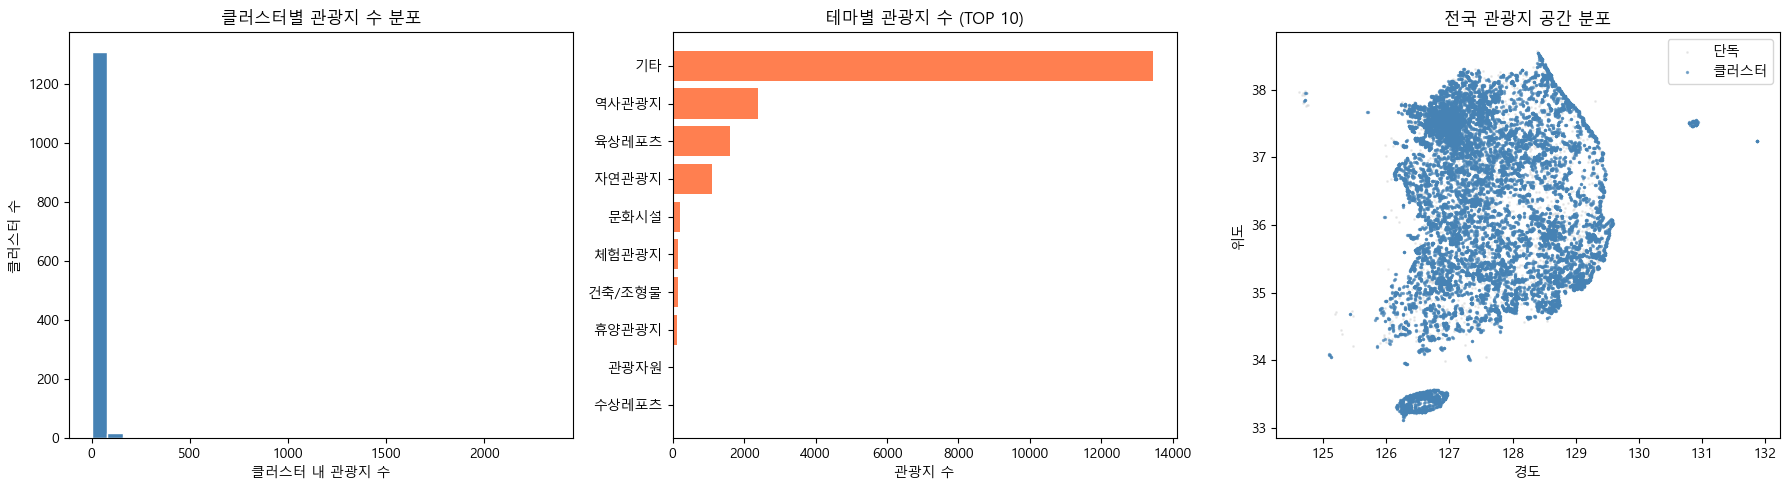

✅ 시각화 저장 완료


In [5]:
# ── 셀 6: 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sizes = df[df['space_cluster']!=-1]['space_cluster'].value_counts()
axes[0].hist(sizes.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('클러스터별 관광지 수 분포')
axes[0].set_xlabel('클러스터 내 관광지 수')
axes[0].set_ylabel('클러스터 수')

theme_counts = df['cluster_theme'].value_counts().head(10)
axes[1].barh(theme_counts.index[::-1], theme_counts.values[::-1], color='coral')
axes[1].set_title('테마별 관광지 수 (TOP 10)')
axes[1].set_xlabel('관광지 수')

noise    = df[df['space_cluster'] == -1]
clustered= df[df['space_cluster'] != -1]
axes[2].scatter(noise['longitude'],    noise['latitude'],    c='lightgray', s=1, alpha=0.4, label='단독')
axes[2].scatter(clustered['longitude'],clustered['latitude'],c='steelblue', s=2, alpha=0.6, label='클러스터')
axes[2].set_title('전국 관광지 공간 분포')
axes[2].set_xlabel('경도'); axes[2].set_ylabel('위도')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 시각화 저장 완료')

In [6]:
# ── 셀 7: 대형 클러스터 샘플 확인 ────────────────────────────
min_size = df[df['space_cluster']!=-1]['cluster_size'].quantile(0.75)
print(f'상위 25% 클러스터 기준: {min_size:.0f}개 이상\n')

large = (
    df[df['cluster_size'] >= min_size]
    .groupby('cluster_id')
    .agg(
        size =('cluster_size','first'),
        theme=('cluster_theme','first'),
        area =('cluster_area','first'),
        sites=('name', lambda x: ' / '.join(x.head(4).tolist()))
    )
    .sort_values('size', ascending=False)
    .head(10)
)

print('=== 대형 클러스터 TOP 10 ===')
for _, row in large.iterrows():
    print(f"\n[{row['area']} / {row['theme']}] {row['size']}개")
    print(f"  {row['sites']} ...")

상위 25% 클러스터 기준: 285개 이상

=== 대형 클러스터 TOP 10 ===

[경기 / 육상레포츠] 2336개
  가금철교 문화공원 / 가나아트파크 / 가루매마을 / 가막들공원 ...

[서울 / 문화시설] 1027개
  가회동성당 / 간데메공원 / 갈산공원 / 감로암(서울) ...

[제주 / 자연관광지] 727개
  가마오름 / 가문이오름(감은이오름) / 가새기오름 / 가세오름 ...

[강원 / 관광지] 367개
  감추사 / 감추해변 / 강남축구공원 / 강릉 3·1운동 기념공원 ...

[경남 / 관광지] 285개
  가라산 / 가배량진성 / 강구안 / 거가대교 ...
